In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

2026-03-03 14:03:08.461741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772546588.661240      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772546588.715852      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772546589.153958      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772546589.154003      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772546589.154005      55 computation_placer.cc:177] computation placer alr

In [2]:
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
DATASET_PATH = "/kaggle/input/datasets/amlelsayed33/model-2/M_2"
IMAGE_SIZE = (224, 224) 
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 10
INITIAL_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_AT = 100  # Unfreeze layers from this point

print("=== Dataset Structure ===")
print("Directory contents:", os.listdir(DATASET_PATH))

=== Dataset Structure ===
Directory contents: ['CONGETION', 'NO CONGESTION']


In [8]:
congetion_count = len(os.listdir(os.path.join(DATASET_PATH, 'CONGETION')))
non_congetion_count = len(os.listdir(os.path.join(DATASET_PATH, 'NO CONGESTION')))

print(f"congetion images: {congetion_count}")
print(f"non_congetion images: {non_congetion_count}")
print(f"Total images: {congetion_count + non_congetion_count}")
print(f"Class balance ratio: {congetion_count/non_congetion_count:.2f}")

congetion images: 3008
non_congetion images: 3000
Total images: 6008
Class balance ratio: 1.00


In [9]:
# Data Generators with improved augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

# Test data generator (without augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
# Load data
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42,
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42,
    shuffle=False  
)

# Print dataset info
print("\n=== Data Generators Info ===")
print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(validation_generator)}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print("Class indices:", train_generator.class_indices)

Found 4807 images belonging to 2 classes.
Found 1201 images belonging to 2 classes.

=== Data Generators Info ===
Training batches: 151
Validation batches: 38
Training samples: 4807
Validation samples: 1201
Class indices: {'CONGETION': 0, 'NO CONGESTION': 1}


🏗️ Building model...


Model: "VGG16_Defect_Detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 27,694,913 (105.65 MB)

 Trainable params: 12,978,689 (49.51 MB)

...

151/151 ━━━━━━━━━━━━━━━━━━━━ 77s 507ms/step - accuracy: 0.9755 - loss: 0.0667 - precision: 0.9720 - recall: 0.9796 - val_accuracy: 0.9617 - val_loss: 0.0912 - val_precision: 0.9511 - val_recall: 0.9733 - learning_rate: 0.0010
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9808 - loss: 0.0555 - precision: 0.9793 - recall: 0.9824
Epoch 3: val_accuracy improved from 0.96170 to 0.97003, saving model to best_congetion_model.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 75s 496ms/step - accuracy: 0.9808 - loss: 0.0555 - precision: 0.9792 - recall: 0.9824 - val_accuracy: 0.9700 - val_loss: 0.1104 - val_precision: 0.9490 - val_recall: 0.9933 - learning_rate: 0.0010
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9811 - loss: 0.0575 - precision: 0.9824 - recall: 0.9802
Epoch 4: val_accuracy did not improve from 0.97003
151/151 ━━━━━━━━━━━━━━━━━━━━ 76s 504ms/step - accuracy: 0.9811 - loss: 0.0575 - precision: 0.9824 - recall: 0.9802 - val_accuracy: 0.9242 - val_loss: 0.2900 - val_precision: 0.8683 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9832 - loss: 0.0524 - precision: 0.9808 - recall: 0.9852
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy did not improve from 0.97003
151/151 ━━━━━━━━━━━━━━━━━━━━ 75s 494ms/step - accuracy: 0.9832 - loss: 0.0525 - precision: 0.9808 - recall: 0.9852 - va

151/151 ━━━━━━━━━━━━━━━━━━━━ 75s 495ms/step - accuracy: 0.9891 - loss: 0.0348 - precision: 0.9893 - recall: 0.9891 - val_accuracy: 0.9717 - val_loss: 0.1975 - val_precision: 0.9464 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.

=== Phase 2: Fine-tuning ===
✅ Unfrozen layers: 4
📊 Total trainable params before fine-tuning: 27694913
Epoch 1/25
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9783 - loss: 0.0648 - precision: 0.9798 - recall: 0.9765
Epoch 1: val_accuracy did not improve from 0.97169
151/151 ━━━━━━━━━━━━━━━━━━━━ 84s 518ms/step - accuracy: 0.9784 - loss: 0.0647 - precision: 0.9798 - recall: 0.9765 - val_accuracy: 0.9717 - val_loss: 0.1901 - val_precision: 0.9464 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/25
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9917 - loss: 0.0243 - precision: 0.9909 - recall: 0.9924
Epoch 2: val_accuracy did not improve from 0.97169



💾 Saving final model...
✅ Model saved successfully!

🧪 Testing model loading...


✅ Model loaded successfully!
✅ Test prediction works! Output shape: (1, 1)


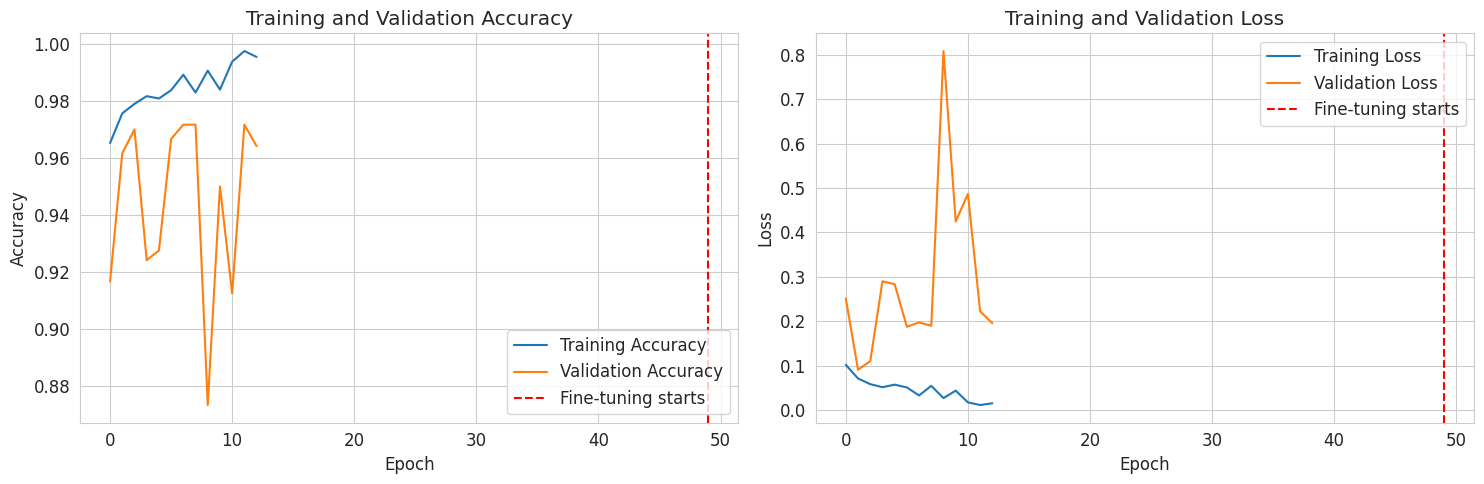

✅ Training history plot saved!

✅ Training completed successfully!

📁 Model saved as: congestion_detection_model_final.h5
📁 Best model saved as: best_congestion_model.h5
📊 Training plot saved as: training_history.png


In [ ]:
"""
Fixed VGG16 Training Code - Using Functional API
This fixes the 'list' object has no attribute 'shape' error
"""

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model  
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Hyperparameters
INITIAL_LEARNING_RATE = 0.001
FINE_TUNE_LEARNING_RATE = 0.0001
INITIAL_EPOCHS = 50
FINE_TUNE_EPOCHS = 25
FINE_TUNE_AT = 15  


def create_model(input_shape=(224, 224, 3)):
    """
    Create VGG16 model using Functional API
    This prevents the Flatten layer error
    """
    
    # Define input
    inputs = Input(shape=input_shape)
    
    # Load pre-trained VGG16 base
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs  
    )
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Build classification head using Functional API
    x = base_model.output  
    x = Flatten()(x)  
    x = Dense(512, activation='relu', name='fc1')(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', name='fc2')(x)
    x = Dropout(0.3)(x)
    x = BatchNormalization()(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)
    
    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='VGG16_Defect_Detection')
    
    return model, base_model


# Create model
print(" Building model...")
model, base_model = create_model()
model.summary()

# Callbacks
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Save best model
    ModelCheckpoint(
        'best_congetion_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Phase 1: Initial Training (Feature Extraction)
print("\n" + "="*50)
print("=== Phase 1: Initial Training (Feature Extraction) ===")
print("="*50)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

history_phase1 = model.fit(
    train_generator,
    epochs=INITIAL_EPOCHS,
    validation_data=validation_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=callbacks,
    verbose=1
)

# Phase 2: Fine-tuning
print("\n" + "="*50)
print("=== Phase 2: Fine-tuning ===")
print("="*50)

# Unfreeze top layers of base model
base_model.trainable = True

# Fine-tune from FINE_TUNE_AT layer onwards
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_layers = [l for l in base_model.layers if l.trainable]
print(f" Unfrozen layers: {len(trainable_layers)}")
print(f" Total trainable params before fine-tuning: {model.count_params()}")

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Continue training
history_phase2 = model.fit(
    train_generator,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=validation_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=callbacks,
    verbose=1
)

# Save final model properly
print("\n Saving final model...")
model.save('congestion_detection_model_final.h5')
print(" Model saved successfully!")

# Test loading the saved model
print("\n Testing model loading...")
try:
    loaded_model = tf.keras.models.load_model('congestion_detection_model_final.h5')
    print(" Model loaded successfully!")
    
    # Test prediction
    import numpy as np
    test_input = np.random.rand(1, 224, 224, 3)
    test_pred = loaded_model.predict(test_input, verbose=0)
    print(f" Test prediction works! Output shape: {test_pred.shape}")
    
except Exception as e:
    print(f" Error loading model: {e}")

# Plot training history
import matplotlib.pyplot as plt

def plot_training_history(history1, history2):
    """Plot combined training history"""
    
    # Combine histories
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(15, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=INITIAL_EPOCHS-1, color='r', linestyle='--', label='Fine-tuning starts')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=INITIAL_EPOCHS-1, color='r', linestyle='--', label='Fine-tuning starts')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(" Training history plot saved!")

# Plot history
plot_training_history(history_phase1, history_phase2)

print("\n" + "="*50)
print(" Training completed successfully!")
print("="*50)
print(f"\n Model saved as: congestion_detection_model_final.h5")
print(f" Best model saved as: best_congestion_model.h5")
print(f" Training plot saved as: training_history.png")

In [13]:
from tensorflow import keras


model = keras.models.load_model("best_congetion_model.h5")


model.save("best_congetion_model.keras")

In [14]:
# Combine training histories
def combine_histories(hist1, hist2):
    combined_history = {}
    for key in hist1.history.keys():
        combined_history[key] = hist1.history[key] + hist2.history[key]
    return combined_history

total_history = combine_histories(history_phase1, history_phase2)

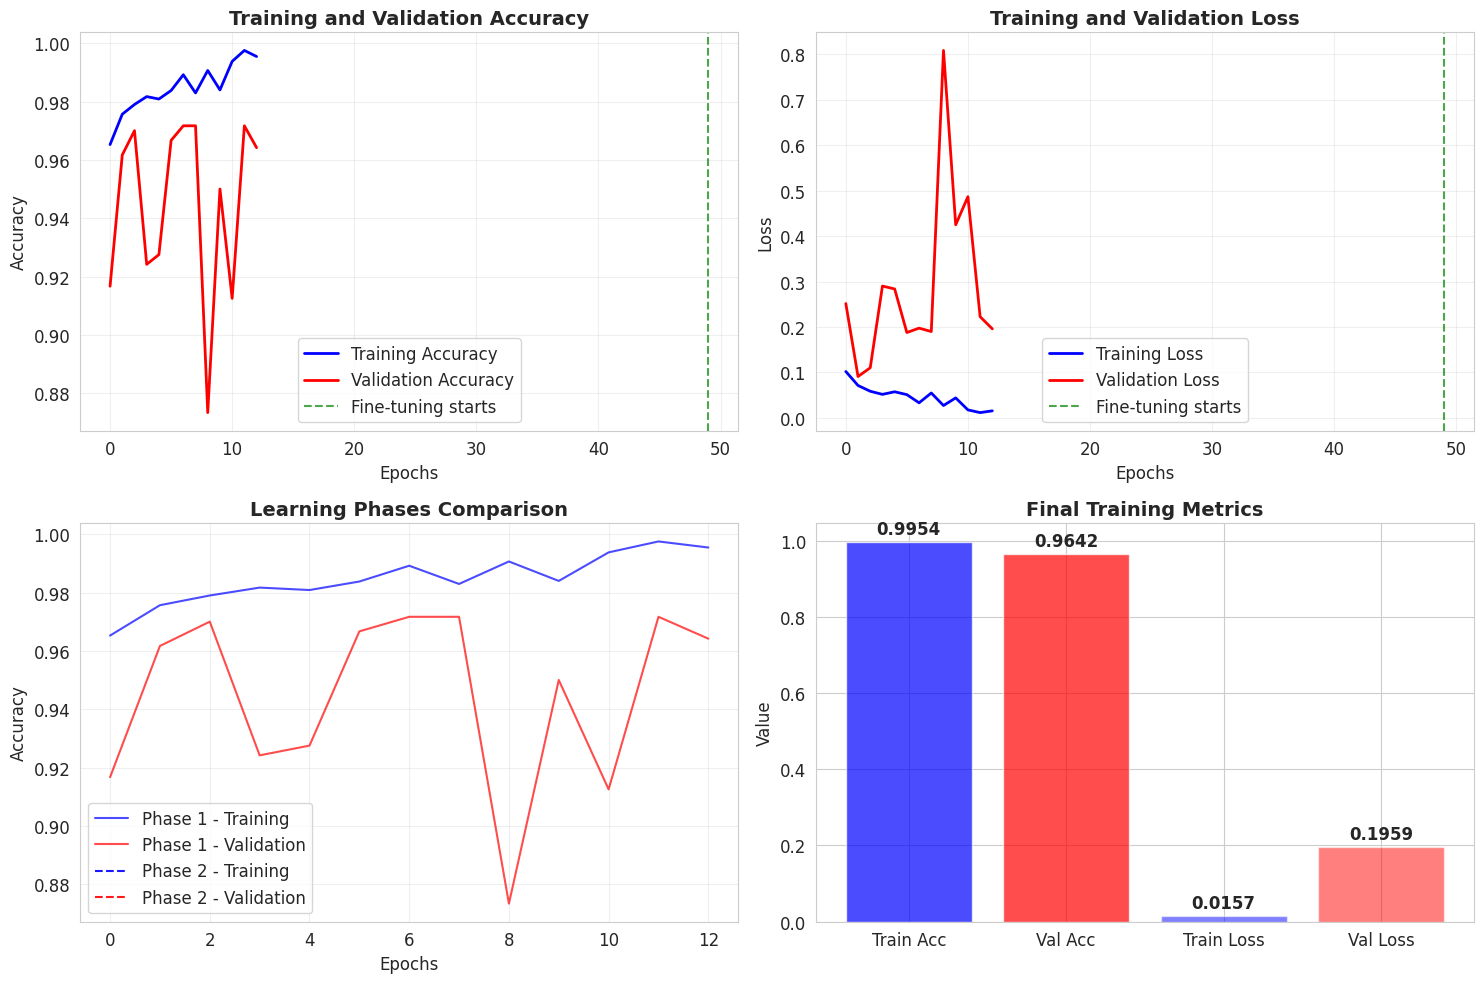

In [15]:
# Plotting Training Results
def plot_training_results(history, phase1_epochs=INITIAL_EPOCHS):
    
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, acc, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    plt.axvline(x=phase1_epochs-1, color='green', linestyle='--', alpha=0.7, label='Fine-tuning starts')
    plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Loss
    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, loss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2)
    plt.axvline(x=phase1_epochs-1, color='green', linestyle='--', alpha=0.7, label='Fine-tuning starts')
    plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Learning curves comparison
    plt.subplot(2, 2, 3)
    plt.plot(epochs_range[:phase1_epochs], acc[:phase1_epochs], 'b-', alpha=0.7, label='Phase 1 - Training')
    plt.plot(epochs_range[:phase1_epochs], val_acc[:phase1_epochs], 'r-', alpha=0.7, label='Phase 1 - Validation')
    plt.plot(epochs_range[phase1_epochs:], acc[phase1_epochs:], 'b--', alpha=0.9, label='Phase 2 - Training')
    plt.plot(epochs_range[phase1_epochs:], val_acc[phase1_epochs:], 'r--', alpha=0.9, label='Phase 2 - Validation')
    plt.title('Learning Phases Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Final metrics
    plt.subplot(2, 2, 4)
    final_metrics = {
        'Train Acc': acc[-1],
        'Val Acc': val_acc[-1],
        'Train Loss': loss[-1],
        'Val Loss': val_loss[-1]
    }
    
    metrics_names = list(final_metrics.keys())
    metrics_values = list(final_metrics.values())
    colors = ['blue', 'red', 'blue', 'red']
    
    # Create bars individually with different alphas
    bars = []
    for i, (name, value, color) in enumerate(zip(metrics_names, metrics_values, colors)):
        alpha_val = 0.7 if 'Acc' in name else 0.5
        bar = plt.bar(name, value, color=color, alpha=alpha_val)
        bars.extend(bar)
    
    plt.title('Final Training Metrics', fontsize=14, fontweight='bold')
    plt.ylabel('Value')
    
    # Add value labels on bars
    for bar, value in zip(bars, metrics_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_training_results(total_history)


=== Model Evaluation ===
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step
Classification Report:
                precision    recall  f1-score   support

Non-Congestion       1.00      0.94      0.97       601
    Congestion       0.95      1.00      0.97       600

      accuracy                           0.97      1201
     macro avg       0.97      0.97      0.97      1201
  weighted avg       0.97      0.97      0.97      1201



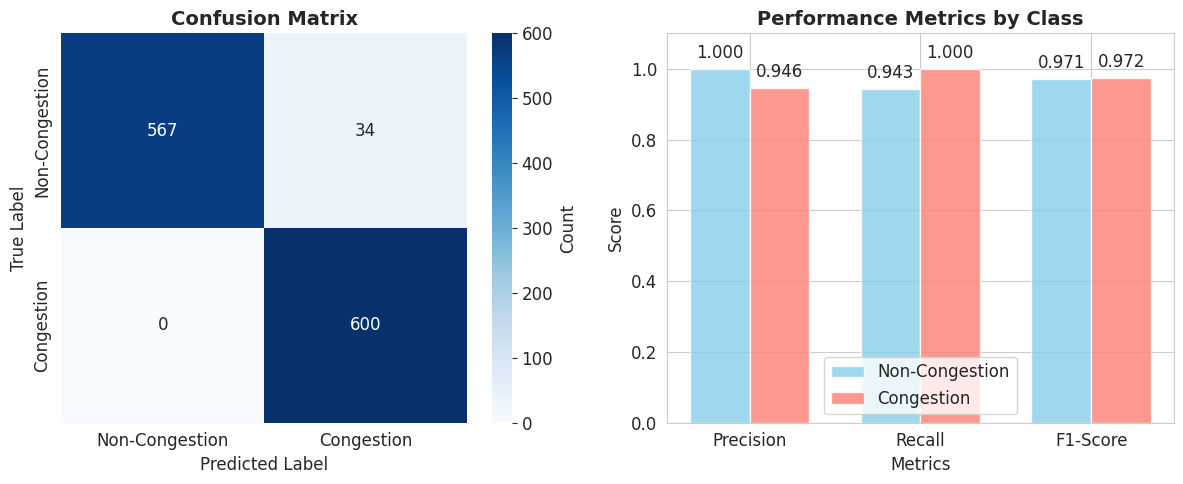


Overall Accuracy: 0.9717
Macro Average F1-Score: 0.9717
Weighted Average F1-Score: 0.9717


In [17]:
# Model Evaluation
def evaluate_model(model, validation_generator):
    
    print("\n=== Model Evaluation ===")
    
    # Get predictions
    validation_generator.reset()
    predictions = model.predict(validation_generator, steps=len(validation_generator))
    y_pred = (predictions > 0.5).astype(int).flatten()
    y_true = validation_generator.labels
    
    # Classification report
    class_names = ['Non-Congestion', 'Congestion']
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 5))
    
    # Plot confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Plot metrics
    plt.subplot(1, 2, 2)
    metrics = ['Precision', 'Recall', 'F1-Score']
    metric_keys = ['precision', 'recall', 'f1-score']  # sklearn uses 'f1-score' not 'f1_score'
    
    Congestion_scores = [report['Congestion'][key] for key in metric_keys]
    non_Congestion_scores = [report['Non-Congestion'][key] for key in metric_keys]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, non_Congestion_scores, width, label='Non-Congestion', alpha=0.8, color='skyblue')
    plt.bar(x + width/2, Congestion_scores, width, label='Congestion', alpha=0.8, color='salmon')
    
    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Performance Metrics by Class', fontsize=14, fontweight='bold')
    plt.xticks(x, metrics)
    plt.legend()
    plt.ylim(0, 1.1)
    
    # Add value labels
    for i, (nd_score, d_score) in enumerate(zip(non_Congestion_scores, Congestion_scores)):
        plt.text(i - width/2, nd_score + 0.02, f'{nd_score:.3f}', ha='center', va='bottom')
        plt.text(i + width/2, d_score + 0.02, f'{d_score:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nOverall Accuracy: {report['accuracy']:.4f}")
    print(f"Macro Average F1-Score: {report['macro avg']['f1-score']:.4f}")
    print(f"Weighted Average F1-Score: {report['weighted avg']['f1-score']:.4f}")
    
    return report, cm, predictions

# Evaluate the model
eval_report, conf_matrix, predictions = evaluate_model(model, validation_generator)

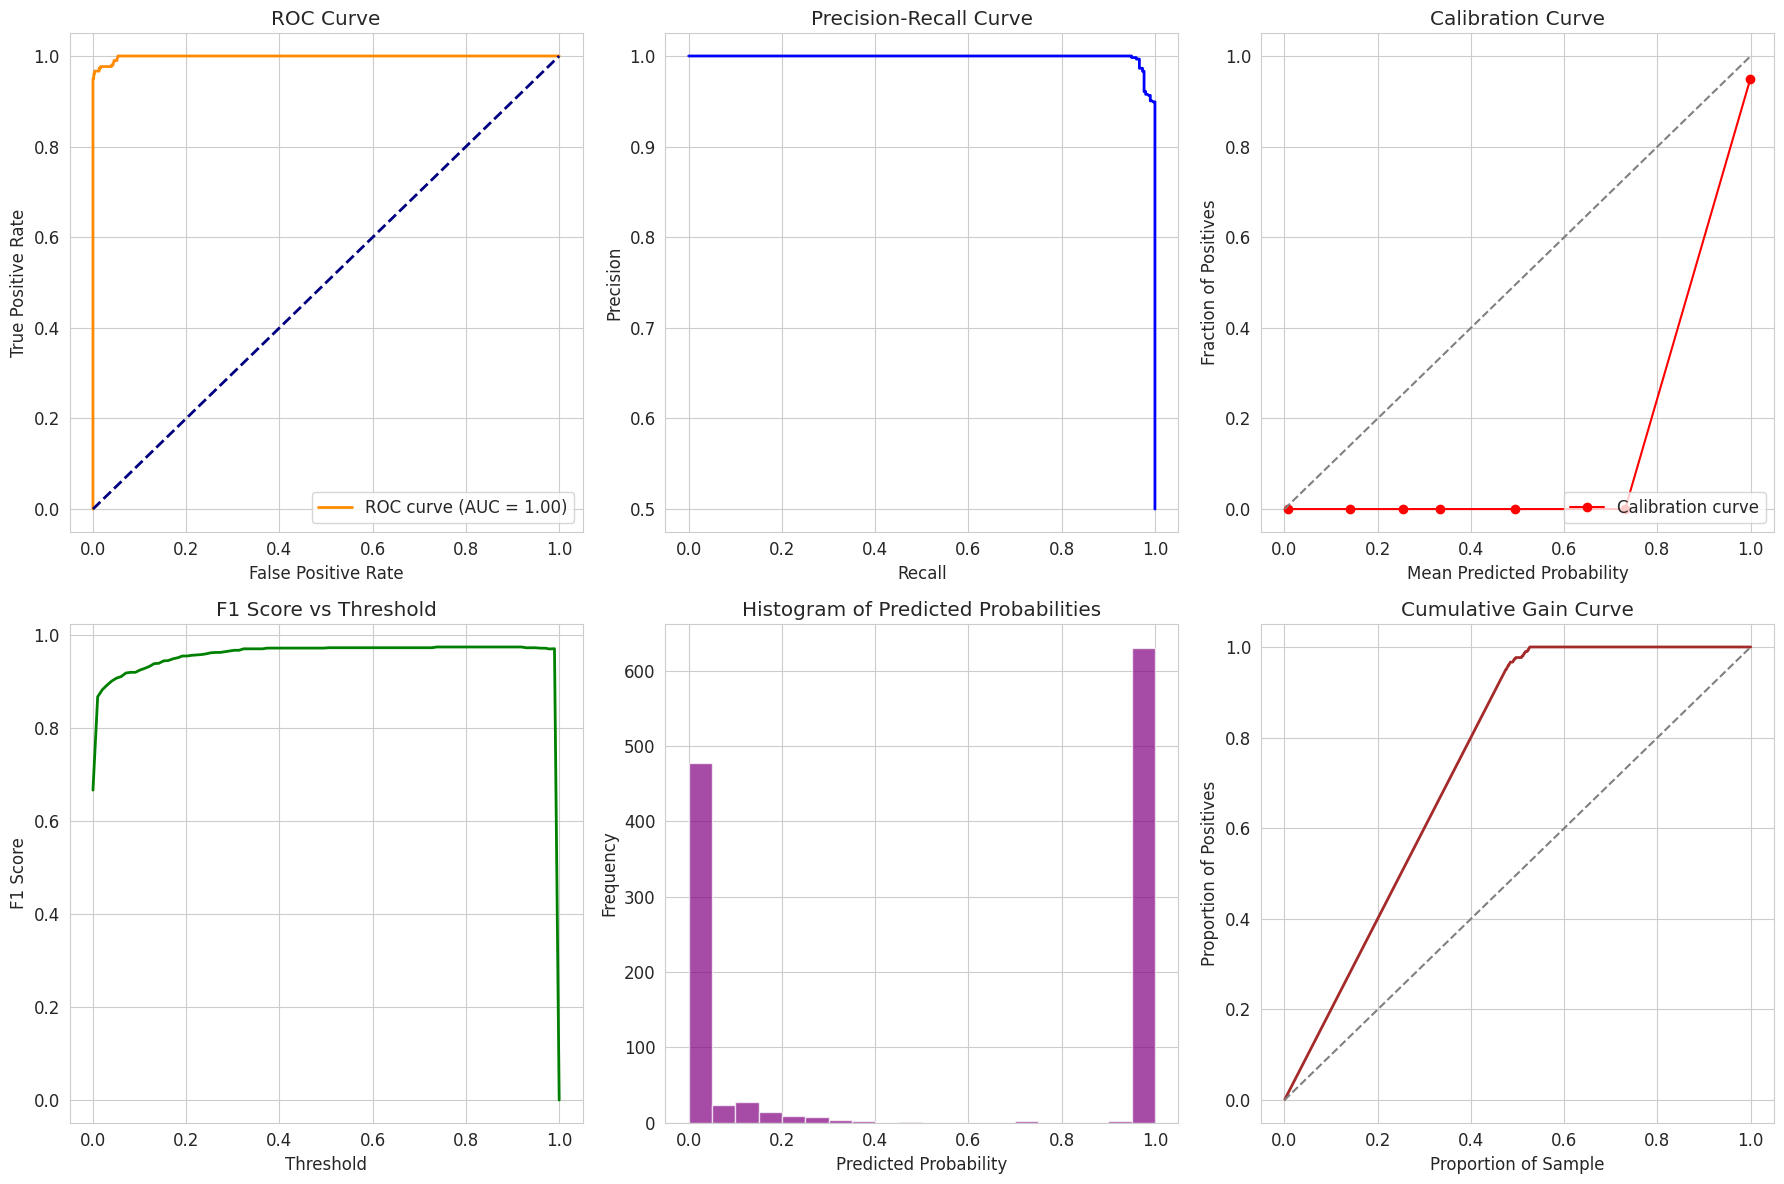

In [18]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
from sklearn.calibration import calibration_curve

# Flatten predictions to 1D array
y_true = validation_generator.labels
y_pred_prob = predictions.flatten()  # probabilities
y_pred = (y_pred_prob > 0.5).astype(int)  # binary predictions

# Set up subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend(loc="lower right")

# === Precision-Recall Curve ===
precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
axes[0, 1].plot(recall, precision, color='blue', lw=2)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')

# === Calibration Curve ===
prob_true, prob_pred = calibration_curve(y_true, y_pred_prob, n_bins=10)
axes[0, 2].plot(prob_pred, prob_true, marker='o', color='red', label='Calibration curve')
axes[0, 2].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0, 2].set_xlabel('Mean Predicted Probability')
axes[0, 2].set_ylabel('Fraction of Positives')
axes[0, 2].set_title('Calibration Curve')
axes[0, 2].legend(loc="lower right")

# === F1 Score Curve ===
thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_true, (y_pred_prob > t).astype(int)) for t in thresholds]
axes[1, 0].plot(thresholds, f1_scores, color='green', lw=2)
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score vs Threshold')

# === Histogram of Predicted Probabilities ===
axes[1, 1].hist(y_pred_prob, bins=20, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Histogram of Predicted Probabilities')

# === Cumulative Gain Curve ===
# Sort probabilities and compute cumulative gain
sorted_idx = np.argsort(-y_pred_prob)
y_sorted = y_true[sorted_idx]
cum_gain = np.cumsum(y_sorted) / np.sum(y_sorted)
percent_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

axes[1, 2].plot(percent_samples, cum_gain, lw=2, color='brown')
axes[1, 2].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1, 2].set_xlabel('Proportion of Sample')
axes[1, 2].set_ylabel('Proportion of Positives')
axes[1, 2].set_title('Cumulative Gain Curve')

plt.tight_layout()
plt.show()

In [19]:
# Prediction function for new images
def predict_defect(model, image_path, threshold=0.5):

    from tensorflow.keras.preprocessing import image
    
    # Load and preprocess image
    img = image.load_img(image_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    
    # Make prediction
    prediction_prob = model.predict(img_array)[0][0]
    prediction = 1 if prediction_prob > threshold else 0
    confidence = prediction_prob if prediction == 1 else 1 - prediction_prob
    
    result = {
        'prediction': 'Congestion' if prediction == 1 else 'Non-Congestion',
        'confidence': confidence,
        'probability': prediction_prob
    }
    
    return result

print("\n🎉 Training Complete! Model is ready for deployment.")
print(f"Final Validation Accuracy: {max(total_history['val_accuracy']):.4f}")
print(f"Final Validation Loss: {min(total_history['val_loss']):.4f}")


🎉 Training Complete! Model is ready for deployment.
Final Validation Accuracy: 0.9717
Final Validation Loss: 0.0912


In [20]:
def predict_defect(model, image_path, threshold=0.5):
    from tensorflow.keras.preprocessing import image
    import numpy as np
    import matplotlib.pyplot as plt

    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    pred = model.predict(img_array)
    print(f"raw pred shape: {pred.shape}")
    print(f"raw pred values: {pred}")

    # interpret sigmoid output (0~1)
    prob = float(pred[0][0])
    
    # FIX: reverse logic
    if prob >= threshold:
        label = 'Non-Congestion'
    else:
        label = 'Congestion'

    print(f"probability(Non-Congestion): {prob}")
    print(f"threshold: {threshold}")
    print(f"label: {label}")

    # show image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label} ({prob:.2f})")
    plt.show()

    return {'prediction': label, 'confidence': prob, 'raw': pred}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
raw pred shape: (1, 1)
raw pred values: [[0.00017731]]
probability(Non-Congestion): 0.0001773131371010095
threshold: 0.5
label: Congestion


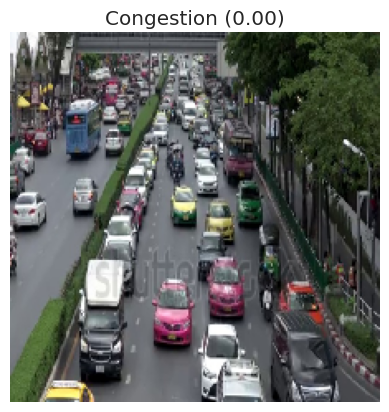

Prediction: Congestion
Confidence: 0.0002


In [22]:
image_path = '/kaggle/input/datasets/amlelsayed33/model-2/M_2/CONGETION/image_1046.jpg'

result = predict_defect(model, image_path)
print(f"Prediction: {result['prediction']}")
print(f"Confidence: {result['confidence']:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
raw pred shape: (1, 1)
raw pred values: [[0.9999999]]
probability(Non-Congestion): 0.9999998807907104
threshold: 0.5
label: Non-Congestion


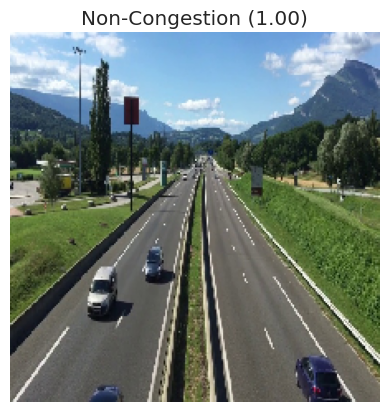

Prediction: Non-Congestion
Confidence: 1.0000


In [23]:
image_path = '/kaggle/input/datasets/amlelsayed33/model-2/M_2/NO CONGESTION/image_0045127420.jpg'

result = predict_defect(model, image_path)
print(f"Prediction: {result['prediction']}")
print(f"Confidence: {result['confidence']:.4f}")

In [24]:
# Create a DataFrame with sample predictions
import pandas as pd

# Example: take 30 samples from validation set
sample_idx = np.random.choice(len(validation_generator.filenames), 30, replace=False)
sample_files = [validation_generator.filenames[i] for i in sample_idx]
sample_true = [validation_generator.classes[i] for i in sample_idx]
sample_pred = predictions[sample_idx].flatten()

# Build DataFrame
df = pd.DataFrame({
    "Image": sample_files,
    "True Label": ["Congestion" if t == 1 else "Non-Congestion" for t in sample_true],
    "Predicted Probabilities": sample_pred,
    "Predicted Label": ["Congestion" if p > 0.5 else "Non-Congestion" for p in sample_pred]
})

# Style DataFrame
styled_df = df.style.set_properties(**{'text-align': 'center'}) \
                   .set_caption("Sample Predictions and Actual Labels") \
                   .format({"Predicted Probabilities": "{:.4f}"}) \
                   .background_gradient(cmap='viridis', subset=["Predicted Probabilities"])

styled_df


,Image,True Label,Predicted Probabilities,Predicted Label
0,CONGETION/image_109000000.jpg,Non-Congestion,0.0002,Non-Congestion
1,NO CONGESTION/image_114532941119 - Copy.jpg,Congestion,1.0000,Congestion
2,CONGETION/image_12345203.jpg,Non-Congestion,0.0153,Non-Congestion
3,CONGETION/image_1234545.jpg,Non-Congestion,0.0940,Non-Congestion
4,NO CONGESTION/image_114532941055.jpg,Congestion,1.0000,Congestion
5,CONGETION/image_1178 - Copy.jpg,Non-Congestion,0.0008,Non-Congestion
6,CONGETION/image_1137.jpg,Non-Congestion,0.0009,Non-Congestion
7,NO CONGESTION/image_11453294937 - Copy.jpg,Congestion,1.0000,Congestion
8,CONGETION/image_12345222.jpg,Non-Congestion,0.0066,Non-Congestion
9,CONGETION/image_120000.jpg,Non-Congestion,0.0010,Non-Congestion
